In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


In [18]:
img_near_color_set1 = cv2.imread("./Input_Images/Set1/Near.bmp")
img_far_color_set1 = cv2.imread("./Input_Images/Set1/Far.bmp")

img_near_set1 = cv2.cvtColor(img_near_color_set1, cv2.COLOR_BGR2GRAY)
img_far_set1 = cv2.cvtColor(img_far_color_set1, cv2.COLOR_BGR2GRAY)

img_near_set1 = img_near_set1.astype(np.float32)
img_far_set1 = img_far_set1.astype(np.float32)

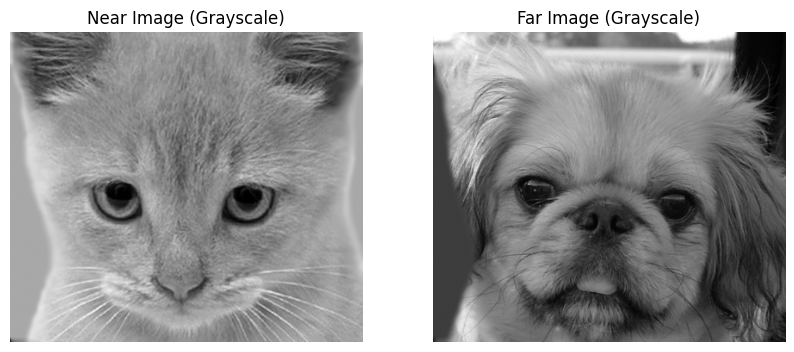

In [19]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_near_set1, cmap='gray')
plt.title("Near Image (Grayscale)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_far_set1, cmap='gray')
plt.title("Far Image (Grayscale)")
plt.axis('off')

plt.show()

In [20]:
img_near_color_set2 = cv2.imread("./Input_Images/Set2/Near.jpg")
img_far_color_set2 = cv2.imread("./Input_Images/Set2/Far.jpg")

img_near_set2 = cv2.cvtColor(img_near_color_set2, cv2.COLOR_BGR2GRAY)
img_far_set2 = cv2.cvtColor(img_far_color_set2, cv2.COLOR_BGR2GRAY)

img_near_set2 = img_near_set2.astype(np.float32)
img_far_set2 = img_far_set2.astype(np.float32)

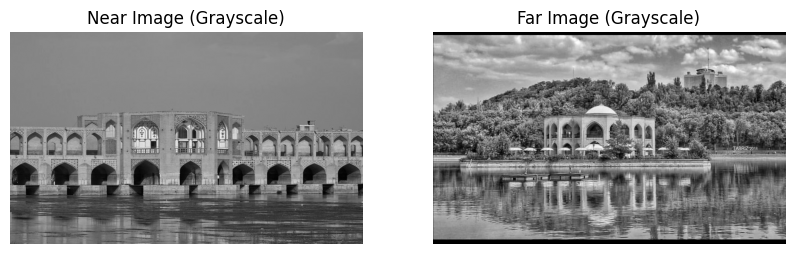

In [21]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_near_set2, cmap='gray')
plt.title("Near Image (Grayscale)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_far_set2, cmap='gray')
plt.title("Far Image (Grayscale)")
plt.axis('off')

plt.show()

In [25]:
def generate_laplacian_pyramid(img, levels=8):
    gaussian_pyramid = [img]
    
    current_img = img
    for i in range(levels - 1):
        current_img = cv2.pyrDown(current_img)
        gaussian_pyramid.append(current_img)
        
    laplacian_pyramid = []
    
    for i in range(levels - 1):
        gaussian_current = gaussian_pyramid[i]
        gaussian_next = gaussian_pyramid[i + 1]
        
        gaussian_expanded = cv2.pyrUp(gaussian_next)
        
        h, w = gaussian_current.shape
        gaussian_expanded = gaussian_expanded[:h, :w]
        
        laplacian = cv2.subtract(gaussian_current, gaussian_expanded)
        laplacian_pyramid.append(laplacian)
        
    laplacian_pyramid.append(gaussian_pyramid[-1])
    
    return laplacian_pyramid

In [26]:
def build_composite_pyramid(pyramid):
    total_width = sum([img.shape[1] for img in pyramid])
    max_height = pyramid[0].shape[0]
    
    composite = np.zeros((max_height, total_width), dtype=np.float32)
    
    current_x = 0
    for img in pyramid:
        h, w = img.shape
        
        normalized_img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
        
        composite[0:h, current_x:current_x + w] = normalized_img
    
        current_x += w
        
    return composite


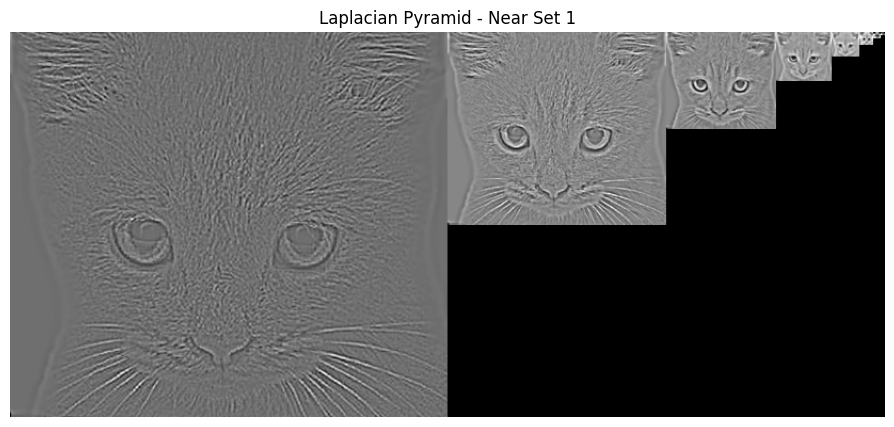

In [27]:
output_dir = "./Output_Images/Part_1"
pyr_near_set1 = generate_laplacian_pyramid(img_near_set1, levels=8)
pyr_far_set1 = generate_laplacian_pyramid(img_far_set1, levels=8)

comp_near_set1 = build_composite_pyramid(pyr_near_set1)
comp_far_set1 = build_composite_pyramid(pyr_far_set1)

cv2.imwrite(f"{output_dir}/Laplacian_Near_Set1.jpg", comp_near_set1)
cv2.imwrite(f"{output_dir}/Laplacian_Far_Set1.jpg", comp_far_set1)

pyr_near_set2 = generate_laplacian_pyramid(img_near_set2, levels=8)
pyr_far_set2 = generate_laplacian_pyramid(img_far_set2, levels=8)

comp_near_set2 = build_composite_pyramid(pyr_near_set2)
comp_far_set2 = build_composite_pyramid(pyr_far_set2)

cv2.imwrite(f"{output_dir}/Laplacian_Near_Set2.jpg", comp_near_set2)
cv2.imwrite(f"{output_dir}/Laplacian_Far_Set2.jpg", comp_far_set2)

plt.figure(figsize=(15, 5))
plt.imshow(comp_near_set1, cmap='gray')
plt.title("Laplacian Pyramid - Near Set 1")
plt.axis('off')
plt.show()

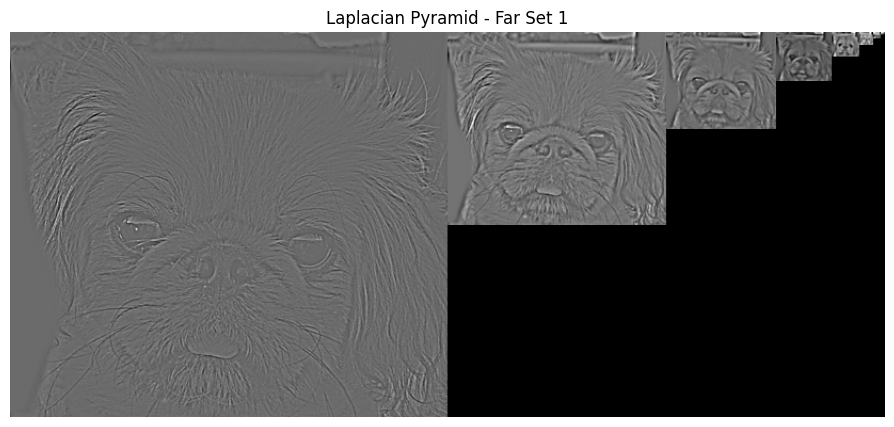

In [29]:
plt.figure(figsize=(15, 5))
plt.imshow(comp_far_set1, cmap='gray')
plt.title("Laplacian Pyramid - Far Set 1")
plt.axis('off')
plt.show()

In [30]:
def reconstruct_from_laplacian(laplacian_pyramid):
    reconstructed_img = laplacian_pyramid[-1]
    
    for i in range(len(laplacian_pyramid) - 2, -1, -1):
        target_layer = laplacian_pyramid[i]
        
        expanded = cv2.pyrUp(reconstructed_img)
        
        h, w = target_layer.shape
        expanded = expanded[:h, :w]
        
        reconstructed_img = cv2.add(expanded, target_layer)
        
    return reconstructed_img

In [35]:
def create_hybrid_pyramid(pyr_near, pyr_far, cutoff=3):
    hybrid_pyr = pyr_near[:cutoff] + pyr_far[cutoff:]
    return hybrid_pyr

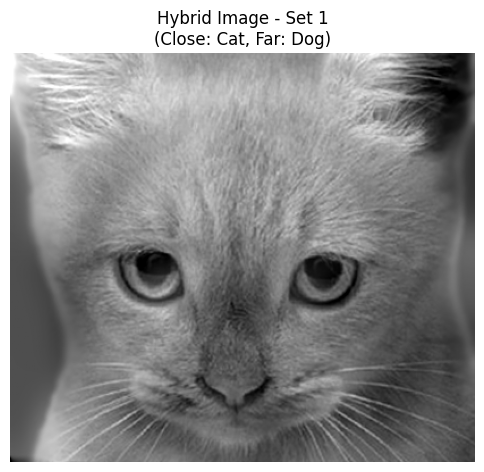

In [33]:
output_dir_part2 = "./Output_Images/Part_2"
hybrid_pyr_set1 = create_hybrid_pyramid(pyr_near_set1, pyr_far_set1)
hybrid_img_set1 = reconstruct_from_laplacian(hybrid_pyr_set1)

hybrid_pyr_set2 = create_hybrid_pyramid(pyr_near_set2, pyr_far_set2)
hybrid_img_set2 = reconstruct_from_laplacian(hybrid_pyr_set2)

hybrid_img_set1_display = np.clip(hybrid_img_set1, 0, 255).astype(np.uint8)
hybrid_img_set2_display = np.clip(hybrid_img_set2, 0, 255).astype(np.uint8)

cv2.imwrite(f"{output_dir_part2}/Hybrid_Set1.jpg", hybrid_img_set1_display)
cv2.imwrite(f"{output_dir_part2}/Hybrid_Set2.jpg", hybrid_img_set2_display)

plt.figure(figsize=(6, 6))
plt.imshow(hybrid_img_set1_display, cmap='gray')
plt.title("Hybrid Image - Set 1\n(Close: Cat, Far: Dog)")
plt.axis('off')
plt.show()

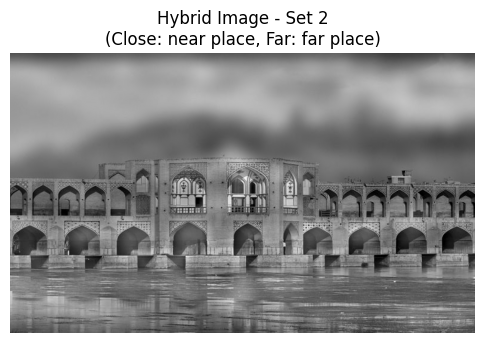

In [34]:
plt.figure(figsize=(6, 6))
plt.imshow(hybrid_img_set2_display, cmap='gray')
plt.title("Hybrid Image - Set 2\n(Close: near place, Far: far place)")
plt.axis('off')
plt.show()

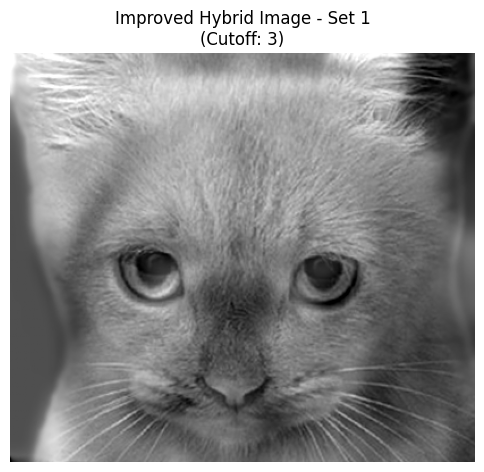

In [38]:
hybrid_pyr_set1_improved = create_hybrid_pyramid(pyr_near_set1, pyr_far_set1, cutoff=3)
hybrid_img_set1_improved = reconstruct_from_laplacian(hybrid_pyr_set1_improved)

hybrid_img_set1_display_improved = np.clip(hybrid_img_set1_improved, 0, 255).astype(np.uint8)

cv2.imwrite(f"{output_dir_part2}/Hybrid_Set1_Improved.jpg", hybrid_img_set1_display_improved)

plt.figure(figsize=(6, 6))
plt.imshow(hybrid_img_set1_display_improved, cmap='gray')
plt.title("Improved Hybrid Image - Set 1\n(Cutoff: 3)")
plt.axis('off')
plt.show()

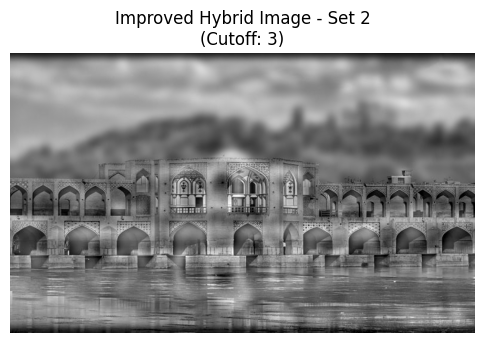

In [37]:
hybrid_pyr_set2_improved = create_hybrid_pyramid(pyr_near_set2, pyr_far_set2, cutoff=3)
hybrid_img_set2_improved = reconstruct_from_laplacian(hybrid_pyr_set2_improved)

hybrid_img_set2_display_improved = np.clip(hybrid_img_set2_improved, 0, 255).astype(np.uint8)

cv2.imwrite(f"{output_dir_part2}/Hybrid_Set1_Improved.jpg", hybrid_img_set2_display_improved)

plt.figure(figsize=(6, 6))
plt.imshow(hybrid_img_set2_display_improved, cmap='gray')
plt.title("Improved Hybrid Image - Set 2\n(Cutoff: 3)")
plt.axis('off')
plt.show()

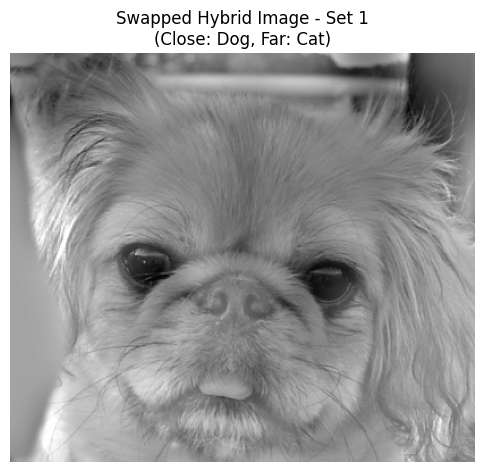

In [39]:
output_dir_part3 = "./Output_Images/Part_3"
hybrid_pyr_swapped_set1 = create_hybrid_pyramid(pyr_far_set1, pyr_near_set1, cutoff=4)
hybrid_img_swapped_set1 = reconstruct_from_laplacian(hybrid_pyr_swapped_set1)

hybrid_pyr_swapped_set2 = create_hybrid_pyramid(pyr_far_set2, pyr_near_set2, cutoff=4)
hybrid_img_swapped_set2 = reconstruct_from_laplacian(hybrid_pyr_swapped_set2)

hybrid_img_swapped_set1_display = np.clip(hybrid_img_swapped_set1, 0, 255).astype(np.uint8)
hybrid_img_swapped_set2_display = np.clip(hybrid_img_swapped_set2, 0, 255).astype(np.uint8)

cv2.imwrite(f"{output_dir_part3}/Hybrid_Swapped_Set1.jpg", hybrid_img_swapped_set1_display)
cv2.imwrite(f"{output_dir_part3}/Hybrid_Swapped_Set2.jpg", hybrid_img_swapped_set2_display)

plt.figure(figsize=(6, 6))
plt.imshow(hybrid_img_swapped_set1_display, cmap='gray')
plt.title("Swapped Hybrid Image - Set 1\n(Close: Dog, Far: Cat)")
plt.axis('off')
plt.show()

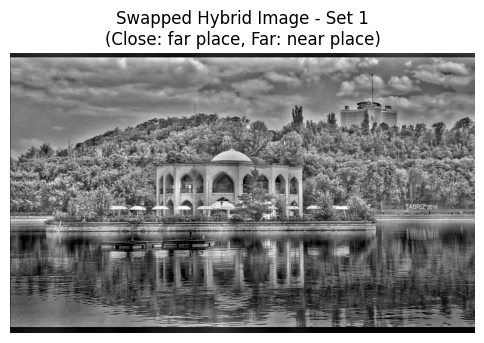

In [41]:
plt.figure(figsize=(6, 6))
plt.imshow(hybrid_img_swapped_set2_display, cmap='gray')
plt.title("Swapped Hybrid Image - Set 1\n(Close: far place, Far: near place)")
plt.axis('off')
plt.show()

In [42]:
def create_linear_hybrid_pyramid(pyr_near, pyr_far):
    hybrid_pyr = []
    
    for j in range(8):
        weight_far = j / 7.0
        weight_near = 1.0 - weight_far
        
        hybrid_layer = (weight_near * pyr_near[j]) + (weight_far * pyr_far[j])
        hybrid_pyr.append(hybrid_layer)
        
    return hybrid_pyr

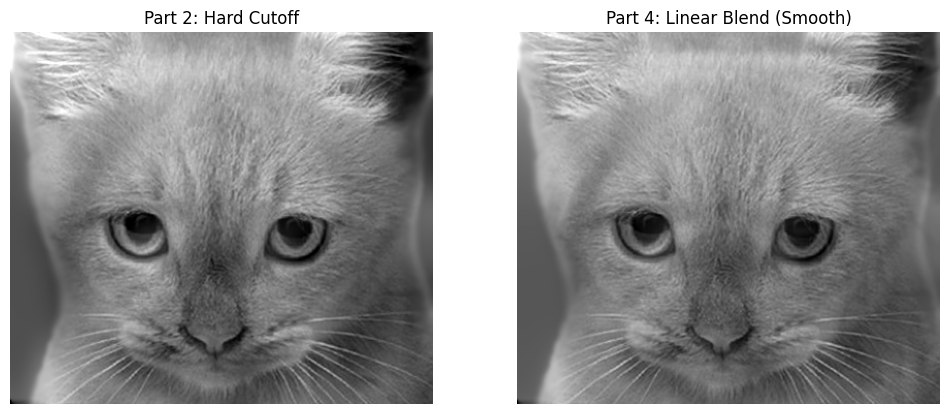

In [43]:
output_dir_part4 = "./Output_Images/Part_4"
hybrid_linear_pyr_set1 = create_linear_hybrid_pyramid(pyr_near_set1, pyr_far_set1)
hybrid_linear_img_set1 = reconstruct_from_laplacian(hybrid_linear_pyr_set1)

comp_linear_hybrid_set1 = build_composite_pyramid(hybrid_linear_pyr_set1)

hybrid_linear_pyr_set2 = create_linear_hybrid_pyramid(pyr_near_set2, pyr_far_set2)
hybrid_linear_img_set2 = reconstruct_from_laplacian(hybrid_linear_pyr_set2)

comp_linear_hybrid_set2 = build_composite_pyramid(hybrid_linear_pyr_set2)

hybrid_linear_img_set1_display = np.clip(hybrid_linear_img_set1, 0, 255).astype(np.uint8)
hybrid_linear_img_set2_display = np.clip(hybrid_linear_img_set2, 0, 255).astype(np.uint8)

cv2.imwrite(f"{output_dir_part4}/Hybrid_Linear_Set1.jpg", hybrid_linear_img_set1_display)
cv2.imwrite(f"{output_dir_part4}/Laplacian_Pyramid_Linear_Set1.jpg", comp_linear_hybrid_set1)

cv2.imwrite(f"{output_dir_part4}/Hybrid_Linear_Set2.jpg", hybrid_linear_img_set2_display)
cv2.imwrite(f"{output_dir_part4}/Laplacian_Pyramid_Linear_Set2.jpg", comp_linear_hybrid_set2)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(hybrid_img_set1_display, cmap='gray') 
plt.title("Part 2: Hard Cutoff")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hybrid_linear_img_set1_display, cmap='gray')
plt.title("Part 4: Linear Blend (Smooth)")
plt.axis('off')

plt.show()

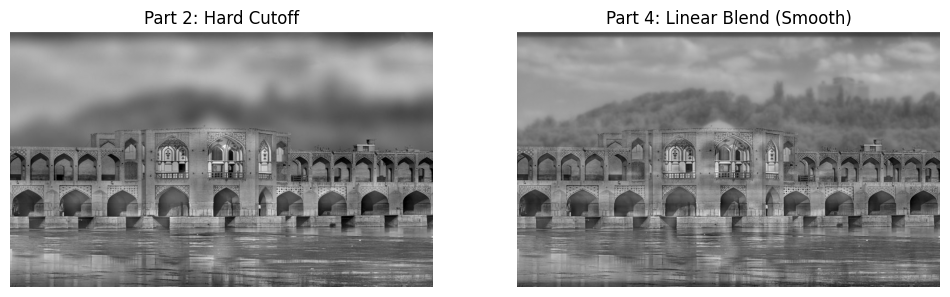

In [44]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(hybrid_img_set2_display, cmap='gray') 
plt.title("Part 2: Hard Cutoff")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hybrid_linear_img_set2_display, cmap='gray')
plt.title("Part 4: Linear Blend (Smooth)")
plt.axis('off')

plt.show()